# Q-learning

### Learning to walk along a cliff without being told how

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How an agent learns from reward alone, what the Bellman equation is doing, how to write Q-learning in thirty lines, and the one-word difference between Q-learning and SARSA that changes the route they take |
| **You should already know** | Python and NumPy. No prior reinforcement learning needed |
| **Environment** | Cliff Walking, built from scratch in this notebook |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [11-05 SARSA](../05-sarsa/) · [11-06 Deep Q-Networks](../06-deep-q-networks/) |

---

## 1. The idea

Everything else in this book learns from answers. You hand the model a bean and
the word DERMASON, and it adjusts.

Reinforcement learning has no answers. An agent takes an action, the world
responds with a number, and that is all it gets. Nobody says which action was
correct. The agent must work out, from delayed and noisy reward, which of its
past choices deserve the credit.

The problem in one sentence: **you find out that a decision was bad long after
you made it.** Walking off a cliff on step 14 is caused by turning the wrong way
on step 3, and the reward signal has to travel back that far.

### The environment

A 4 by 12 grid. Start at the bottom left, goal at the bottom right. The eleven
squares between them are a cliff.

- Every step costs **-1**, so dawdling is punished
- Stepping onto the cliff costs **-100** and throws you back to the start
- Reaching the goal ends the episode

There is a short dangerous route straight along the cliff edge, and a long safe
route up and over. That tension is the entire point of this notebook.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

ROWS, COLS = 4, 12
UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
MOVES = {UP: (-1, 0), RIGHT: (0, 1), DOWN: (1, 0), LEFT: (0, -1)}
ARROWS = {UP: "↑", RIGHT: "→", DOWN: "↓", LEFT: "←"}


class CliffWalk:
    """The classic cliff-walking task, written out in full.

    States are numbered row-major, 0 to 47. The bottom row between the start and
    the goal is the cliff.
    """

    start = (ROWS - 1, 0)
    goal = (ROWS - 1, COLS - 1)

    n_states = ROWS * COLS
    n_actions = 4

    def reset(self):
        self.position = self.start
        return self._index(self.position)

    def step(self, action):
        row, col = self.position
        d_row, d_col = MOVES[action]

        # Walls are sticky: bumping into the edge leaves you where you were.
        row = min(max(row + d_row, 0), ROWS - 1)
        col = min(max(col + d_col, 0), COLS - 1)
        self.position = (row, col)

        if self._is_cliff((row, col)):
            self.position = self.start
            return self._index(self.position), -100.0, False

        done = (row, col) == self.goal
        return self._index((row, col)), -1.0, done

    @staticmethod
    def _is_cliff(cell):
        row, col = cell
        return row == ROWS - 1 and 0 < col < COLS - 1

    @staticmethod
    def _index(cell):
        return cell[0] * COLS + cell[1]


env = CliffWalk()
print(f"{env.n_states} states, {env.n_actions} actions")
print(f"start {env.start}, goal {env.goal}, cliff = bottom row columns 1 to {COLS - 2}")

48 states, 4 actions
start (3, 0), goal (3, 11), cliff = bottom row columns 1 to 10


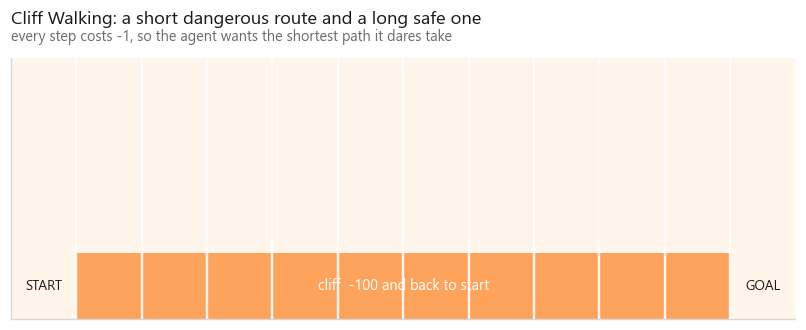

In [2]:
fig, ax = plt.subplots(figsize=(9.2, 3.4))

board = np.zeros((ROWS, COLS))
for c in range(1, COLS - 1):
    board[ROWS - 1, c] = 1

ax.imshow(board, cmap="Oranges", vmin=0, vmax=2.4)
ax.text(0, ROWS - 1, "START", ha="center", va="center", fontsize=9, color=style.INK)
ax.text(COLS - 1, ROWS - 1, "GOAL", ha="center", va="center", fontsize=9, color=style.INK)
ax.text((COLS - 1) / 2, ROWS - 1, "cliff  -100 and back to start",
        ha="center", va="center", fontsize=9.5, color="white")

ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.6)
ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
ax.grid(which="major", visible=False)
style.title(ax, "Cliff Walking: a short dangerous route and a long safe one",
            "every step costs -1, so the agent wants the shortest path it dares take")
style.save(fig, FIG / "fig-01-environment.png")

## 2. The maths

Define $Q(s, a)$ as the total future reward the agent expects if it takes action
$a$ in state $s$ and behaves well afterwards. If you knew $Q$ exactly, acting
optimally would be trivial: in every state, pick the action with the largest $Q$.

Two words from [11-01](../01-the-setup/) are worth holding on to here. $Q$ is a
**value**, so it is a number attached to a situation rather than a rule for
acting, except that this one hangs off a state and an action together instead of
a state alone. And what it measures is a **return**, the whole discounted stream
of future reward, rather than the single reward the next step happens to pay.
Every update below is an attempt to get a return estimate out of one reward at a
time.

The **Bellman optimality equation** says $Q$ must be self-consistent. The value
of an action is the immediate reward plus the discounted value of the best
action available next:

$$Q(s, a) = r + \gamma \max_{a'} Q(s', a')$$

The agent does not know $r$ or $s'$ in advance, so it cannot solve this
directly. Instead it plays, and each time it observes a real transition it nudges
its estimate toward what it just saw:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\Big[\underbrace{r + \gamma \max_{a'} Q(s',a') - Q(s,a)}_{\text{temporal difference error}}\Big]$$

The bracketed term is the surprise: the difference between what actually
happened and what the agent expected. $\alpha$ is how far it moves toward the
surprise, $\gamma$ is how much it cares about the future.

The $\max$ is the part to watch. It assumes the agent will act **optimally** from
the next state onward, regardless of what it is actually going to do. That
assumption is the whole difference between this and SARSA, and section 5 shows
what it costs.

### Exploration

An agent that always picks its current best action never discovers anything. The
standard fix is **epsilon-greedy**: with probability $\varepsilon$ act at random,
otherwise act greedily. Without it, the first mediocre route the agent stumbles
into is the one it keeps forever.

## 3. From scratch

In [3]:
def epsilon_greedy(Q, state, epsilon, rng):
    """Explore with probability epsilon, otherwise take the best known action."""
    if rng.random() < epsilon:
        return rng.integers(CliffWalk.n_actions)
    return int(np.argmax(Q[state]))


def train(method="q-learning", episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1, seed=SEED):
    """Q-learning and SARSA differ by one line. Both are written here to show it."""
    rng = np.random.default_rng(seed)
    env = CliffWalk()
    Q = np.zeros((env.n_states, env.n_actions))
    totals = []

    for _ in range(episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon, rng)
        total = 0.0

        for _ in range(400):                      # cap so a bad policy cannot hang
            next_state, reward, done = env.step(action)
            total += reward
            next_action = epsilon_greedy(Q, next_state, epsilon, rng)

            if method == "q-learning":
                # Assume the best possible next action, whatever we actually do.
                target = reward + gamma * Q[next_state].max()
            else:
                # SARSA bootstraps from the action we are genuinely going to take,
                # exploration mistakes included.
                target = reward + gamma * Q[next_state, next_action]

            Q[state, action] += alpha * (target - Q[state, action])
            state, action = next_state, next_action
            if done:
                break

        totals.append(total)

    return Q, np.array(totals)


Q_learn, rewards_q = train("q-learning")
print(f"trained on 500 episodes")
print(f"average reward over the last 50 episodes : {rewards_q[-50:].mean():.1f}")

trained on 500 episodes
average reward over the last 50 episodes : -48.5


### What did it learn?

The greedy policy is just the best action in each state. Drawing it as arrows
shows the route the agent would take if it stopped exploring.

greedy route length: 13 steps (the shortest possible is 13)
climbing to the top row and back down instead: 17 steps


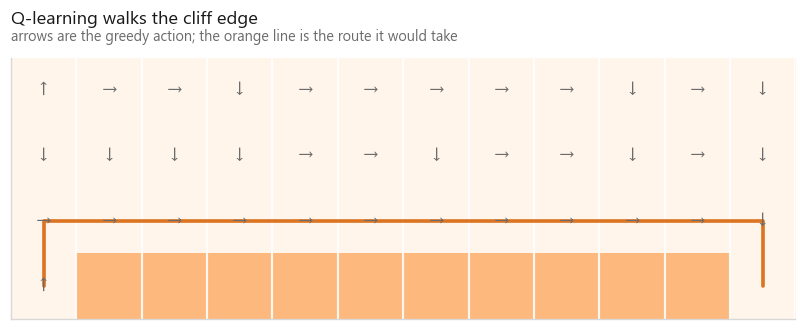

In [4]:
def greedy_path(Q):
    """Follow the greedy policy from the start and record where it goes."""
    env = CliffWalk()
    state = env.reset()
    path = [env.position]
    for _ in range(120):
        state, _, done = env.step(int(np.argmax(Q[state])))
        path.append(env.position)
        if done:
            break
    return path


def draw_policy(ax, Q, title, subtitle=None):
    board = np.zeros((ROWS, COLS))
    for c in range(1, COLS - 1):
        board[ROWS - 1, c] = 1
    ax.imshow(board, cmap="Oranges", vmin=0, vmax=3.0)

    for state in range(CliffWalk.n_states):
        row, col = divmod(state, COLS)
        if CliffWalk._is_cliff((row, col)) or (row, col) == CliffWalk.goal:
            continue
        ax.text(col, row, ARROWS[int(np.argmax(Q[state]))], ha="center", va="center",
                fontsize=13, color=style.MUTED)

    path = greedy_path(Q)
    ax.plot([c for _, c in path], [r for r, _ in path], color=style.HIGHLIGHT,
            lw=2.4, alpha=0.85, solid_capstyle="round")

    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.4)
    ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    ax.grid(which="major", visible=False)
    style.title(ax, title, subtitle)
    return len(path) - 1


fig, ax = plt.subplots(figsize=(9.2, 3.4))
steps = draw_policy(ax, Q_learn, "Q-learning walks the cliff edge",
                    "arrows are the greedy action; the orange line is the route it would take")
style.save(fig, FIG / "fig-02-q-policy.png")
print(f"greedy route length: {steps} steps (the shortest possible is 13)")
print(f"climbing to the top row and back down instead: "
      f"{2 * (ROWS - 1) + (COLS - 1)} steps")

It found the optimal path, straight along the edge of the cliff, one square
from disaster the whole way. That is genuinely the best route by the rules we
wrote: 13 steps, so 13 points of cost, against 17 for climbing to the top row,
crossing along it and coming back down. Section 5 is where something chooses to
pay those four extra steps.

## 4. In practice: the dials

Three hyperparameters. I expected each to fail in its own recognisable way.

mean reward over the last 100 episodes, by setting
  alpha    0.05:   -38.8   0.2:   -43.7   0.5:   -38.8   0.9:   -29.4   | span  14.3
  epsilon  0.01:   -14.2   0.1:   -38.8   0.3:  -165.2   0.6:  -444.5   | span 430.3
  gamma    0.5:   -39.1   0.9:   -36.7   0.99:   -37.9   1.0:   -38.8   | span   2.5


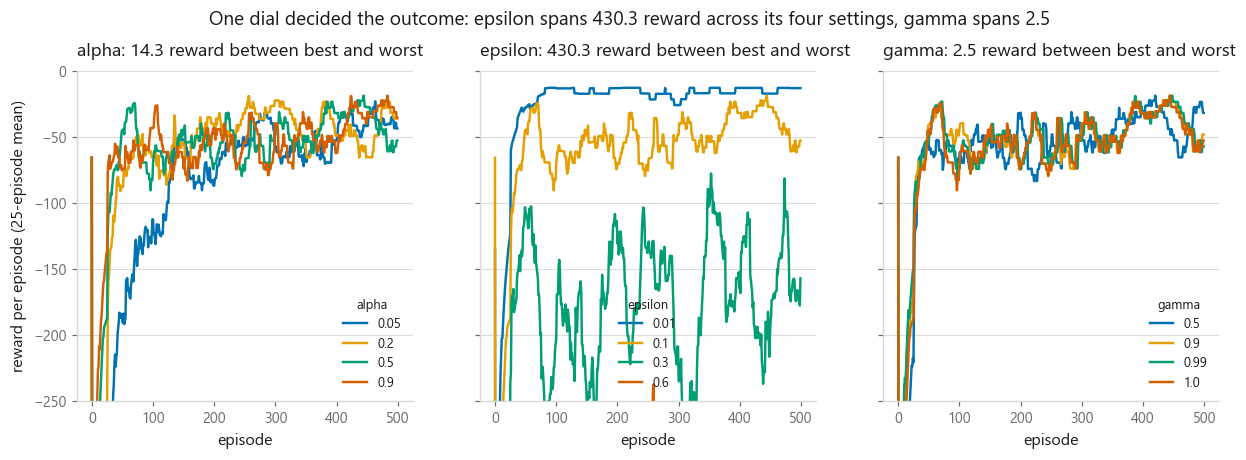

In [5]:
settings = {
    "alpha": [0.05, 0.2, 0.5, 0.9],
    "epsilon": [0.01, 0.1, 0.3, 0.6],
    "gamma": [0.5, 0.9, 0.99, 1.0],
}
defaults = {"alpha": 0.5, "epsilon": 0.1, "gamma": 1.0}

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.9), sharey=True)
settled = {}

for ax, (dial, values) in zip(axes, settings.items()):
    settled[dial] = {}
    for i, value in enumerate(values):
        kwargs = dict(defaults)
        kwargs[dial] = value
        _, rewards = train("q-learning", episodes=500, **kwargs)
        # Where each setting ended up, so the captions can be read off the runs
        # rather than off what a dial is supposed to do.
        settled[dial][value] = rewards[-100:].mean()
        smooth = pd.Series(rewards).rolling(25, min_periods=1).mean()
        ax.plot(smooth, color=style.PALETTE[i], lw=1.6, label=f"{value}")
    ax.set_ylim(-250, 0)
    ax.set_xlabel("episode")
    ax.legend(title=dial, fontsize=8.5, title_fontsize=8.5)
    span = max(settled[dial].values()) - min(settled[dial].values())
    style.title(ax, f"{dial}: {span:.1f} reward between best and worst")

axes[0].set_ylabel("reward per episode (25-episode mean)")
spans = {dial: max(v.values()) - min(v.values()) for dial, v in settled.items()}
widest, narrowest = max(spans, key=spans.get), min(spans, key=spans.get)
fig.suptitle(f"One dial decided the outcome: {widest} spans {spans[widest]:.1f} reward "
             f"across its four settings, {narrowest} spans {spans[narrowest]:.1f}",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-hyperparameters.png")

print("mean reward over the last 100 episodes, by setting")
for dial, values in settled.items():
    print(f"  {dial:<8} " + "   ".join(f"{value}: {score:7.1f}"
                                       for value, score in values.items())
          + f"   | span {spans[dial]:5.1f}")

One of the three dials mattered. Epsilon spans 430.3 reward between its best and
worst setting; alpha spans 14.3 and gamma spans 2.5. Two of those panels are four
lines lying on top of each other, and reading a failure into either of them would
be reading the noise.

**Epsilon**, exploration, is the dial that moves the number, and it did not fail
at the small end. At 0.01 it scores -14.2, the best of any setting anywhere in the
sweep and close to what a perfect 13-step run costs, because an agent that almost
never acts at random almost never walks off the cliff. At 0.6 it scores -444.5:
it spends most of its life acting at random and keeps falling off no matter how
good its $Q$ table gets. The panel is still the clearest illustration in the
notebook that the *behaviour* and the *knowledge* are separate things, but the
cost is all on the behaviour side.

Too little exploration is a real risk on a problem that has somewhere else worth
looking. This one has nowhere: twelve columns, four rows, one route the agent
stumbles into within a few dozen episodes, and nothing better hiding anywhere
else. The textbook failure needs a first route that is not the best one.
Cliff walking does not supply it, so at 0.01 the agent stops looking and is right
to.

**Alpha**, the learning rate, spans 14.3 from 0.05 to 0.9. The visible difference
is at the start rather than the end: at 0.05 the curve climbs slowly through the
first hundred episodes, because each update moves the estimate a twentieth of the
way toward the surprise. It gets there anyway. The thrashing I expected at 0.9 is
not in the panel, and 0.9 settles highest of the four at -29.4. Transitions here
are deterministic and the only noise is the agent's own exploration, which is a
forgiving setting for a large step. A stochastic environment would not be.

**Gamma**, the discount, spans 2.5. At 0.5 it scores -39.2 against 1.0's -38.8,
which is nothing at all. The usual argument does not apply to this environment:
every reward here is -1 or -100 and reaching the goal simply ends the episode, so
there is no distant positive payoff for a discount to shrink toward zero.
Discounting makes future costs cheaper, and since the alternative routes all cost
the same kind of thing, the ranking of the actions available now barely moves.
Gamma bites when a payoff sits at the end of a long chain. Cliff walking has no
such payoff, which is worth knowing before copying a gamma out of a tutorial that
used a different environment.

## 5. When it wins, when it loses

Now the famous comparison. SARSA differs from Q-learning by one term: it
bootstraps from the action it is **actually going to take**, rather than the best
one available. That sounds like a technicality. It changes the route.

Q-learning route : 13 steps
SARSA route      : 17 steps


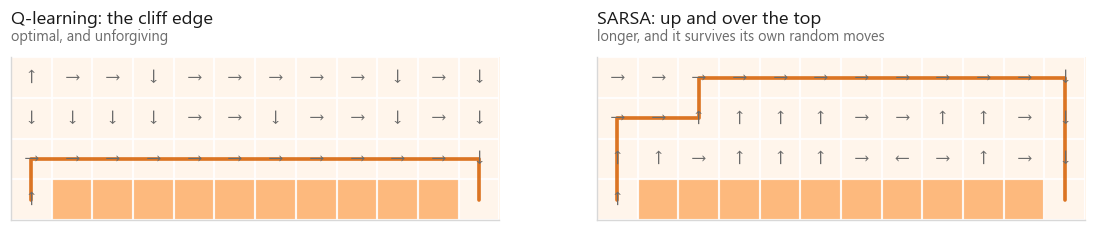

In [6]:
Q_sarsa, rewards_sarsa = train("sarsa")

fig, axes = plt.subplots(1, 2, figsize=(12.6, 3.6))
q_steps = draw_policy(axes[0], Q_learn, "Q-learning: the cliff edge", "optimal, and unforgiving")
s_steps = draw_policy(axes[1], Q_sarsa, "SARSA: up and over the top",
                      "longer, and it survives its own random moves")
style.save(fig, FIG / "fig-04-policies-compared.png")

print(f"Q-learning route : {q_steps} steps")
print(f"SARSA route      : {s_steps} steps")

average reward over the last 100 episodes
  Q-learning :   -38.8
  SARSA      :   -23.9


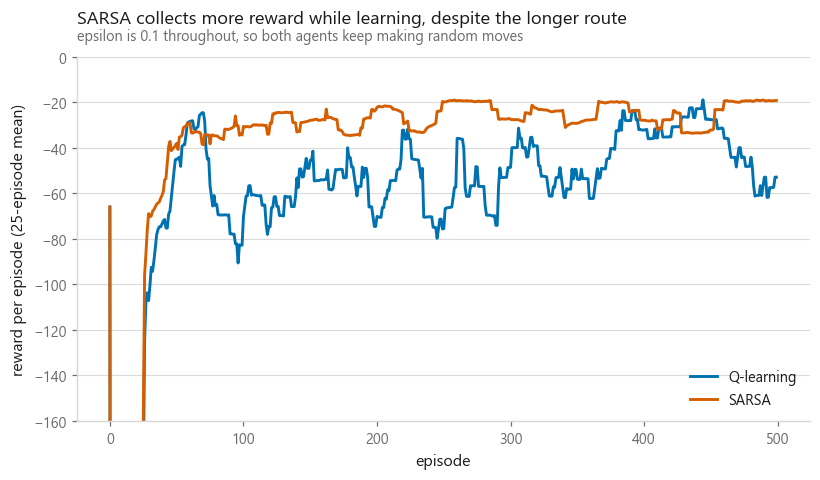

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 4.3))
for rewards, name, colour in [(rewards_q, "Q-learning", style.PALETTE[0]),
                              (rewards_sarsa, "SARSA", style.HIGHLIGHT)]:
    ax.plot(pd.Series(rewards).rolling(25, min_periods=1).mean(), color=colour, label=name)
ax.set_ylim(-160, 0)
ax.set_xlabel("episode")
ax.set_ylabel("reward per episode (25-episode mean)")
ax.legend()
style.title(ax, "SARSA collects more reward while learning, despite the longer route",
            "epsilon is 0.1 throughout, so both agents keep making random moves")
style.save(fig, FIG / "fig-05-learning-curves.png")

print(f"average reward over the last 100 episodes")
print(f"  Q-learning : {rewards_q[-100:].mean():7.1f}")
print(f"  SARSA      : {rewards_sarsa[-100:].mean():7.1f}")

This result is worth slowing down for, because it looks like a contradiction.

Q-learning found the **better policy** and collected the **worse reward**.

Both agents keep exploring at $\varepsilon = 0.1$, so roughly one move in ten is
random. Q-learning's route runs along the cliff edge, where a single random step
downward costs -100 and sends it back to the start. SARSA's update includes that
exploration in its estimates, so it learns that squares beside the cliff are
dangerous *for an agent that sometimes moves at random*, which is exactly what
it is. It climbs to the top row, as far from the edge as the grid allows, and
pays four extra steps for the clearance.

The names for this are **off-policy** and **on-policy**. Q-learning evaluates the
greedy policy while following a different, exploratory one. SARSA evaluates the
policy it is actually running.

Which is right depends entirely on whether the exploration is real. If you are
training in simulation and will deploy greedily, Q-learning's answer is the one
you want. If the agent will keep behaving randomly in the real world (a robot
with noisy actuators, a recommender still running an experiment), then falling
off the cliff is a real cost and SARSA is being correct, not timid.

## Cheat sheet

| | |
|---|---|
| **Use it when** | The state space is small enough to enumerate, and you can simulate many episodes cheaply |
| **Avoid it when** | States are continuous or enormous: that is what [DQN](../06-deep-q-networks/) is for |
| **Off-policy** | Yes, which means it can learn from replayed or borrowed experience. DQN depends on this |
| **Main dials** | `alpha` (0.1 to 0.5), `gamma` (0.9 to 1.0), `epsilon` (0.1, often decayed toward 0). Sweep them before tuning them: here epsilon changed the score by 430.3 and the other two by 14.3 and 2.5 |
| **Guarantee** | Converges to the optimal Q with enough visits to every state-action pair and a decaying alpha |
| **Watch out** | The `max` makes it optimistic, so it overestimates values under noise. Double Q-learning fixes this |
| **Next** | [SARSA](../05-sarsa/) in full, then [DQN](../06-deep-q-networks/) to replace the table with a network |

## What to remember

1. Reinforcement learning has no labels. It has reward, and reward arrives late.
2. $Q(s,a)$ is an expected return, the whole discounted stream of future reward
   rather than the next step's. Know it, and acting well is just `argmax`.
3. The update nudges the estimate toward the observed surprise, by $\alpha$.
4. Without exploration the agent keeps the first route it finds.
5. Q-learning bootstraps from the best next action; SARSA from the one it will
   actually take. That single word decides whether the agent walks along the
   cliff or a row above it.
6. The better policy is not always the one that scores better while learning.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-05 SARSA](../05-sarsa/) · Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#QLearning` `#SARSA` `#MachineLearning` `#Python`
`#RL` `#BellmanEquation` `#MLTutorial` `#LearnMachineLearning` `#AI`